## DATA 320 Midterm Project
|key|value|
|---|-----|
|Author|Nam Nguyen|
|Date|2024-05-23|

## Opening 

# Can sentiment analysis predict movie success?
In the Movie, a movie's success is frequently determined by its box office results and user ratings. While many elements influence a film's appeal, one area that has sparked substantial interest is the sentiment portrayed in movie reviews.


This notebook seeks to determine whether there is a correlation between the general sentiment of movie reviews and the associated user ratings. The primary theory is that movies with more good reviews have higher user ratings, which could indicate greater audience satisfaction and financial success.




## Checking the secret key

In [2]:
import json
with open('secret.json') as f:
    data = json.load(f)

    secret_key = data['mongodb']

# print the length of the secret key.
print(f"My secret key is {len(secret_key)} characters in length.")


My secret key is 61 characters in length.


## Import libraries 

In [3]:
import pymongo
import pandas as pd
import certifi
import re

In [4]:
client = pymongo.MongoClient(secret_key, tlsCAFile=certifi.where())
db = client.DATA320
print(f"Using MongoDB version {client.server_info()['version']}.")

# Check what databases exist on this server
all_databases = client.list_database_names()
print(f"This MongoDB server has the databases {all_databases}")

# If we know the correct database to talk to, we connect like this:
my_database = client['DATA320']

# Here is the list of collections within my database
all_collections = my_database.list_collection_names()
print(f"This database has the collections {all_collections}")

Using MongoDB version 7.0.8.
This MongoDB server has the databases ['DATA320', 'sample_mflix', 'admin', 'local']
This database has the collections ['metacritic', 'imdb_fix', 'imdb_fixed']


In [5]:
imdb_view = pd.DataFrame(db.imdb_fixed.find({"Release_Year":2003}))
imdb_view.head()


,_id,budget,cast,certification,company,director,genres,gross_sales,id,opening_weekend,...,votes,Budget_USD,Gross_Sales_USD,Opening_Weekend_USD,Runtime_minutes,User_Rating_num,Votes_num,Release_Year,Release_Month,MPAA_Rating
0,636b0a183bc31743d94b4eeb,None,"Paul Bettany, Marián Aguilera, Trevor Steedman...",R,"Kanzaman, M.D.A. Films S.L., Renaissance Films",Paul McGuigan,"Crime, Drama, Mystery",None,258816,None,...,6128,NaN,NaN,NaN,112,6.5,6128,2003,8,R
1,636b0e0a3bc31743d94b5080,"$94,000,000 (estimated)","Noel Appleby, Ali Astin, Sean Astin, David Ast...","PG-13, PG-13::(special extended edition)","New Line Cinema, WingNut Films, The Saul Zaent...",Peter Jackson,"Action, Adventure, Drama, Fantasy","$1,119,929,521, 25 Nov 2011",167260,None,...,1833508,94000000.0,1.119930e+09,NaN,201,9.0,1833508,2003,12,PG-13
2,636b0e0d3bc31743d94b5081,"$90,000,000 (estimated)","Eddie Murphy, Terence Stamp, Nathaniel Parker,...",PG,"Walt Disney Pictures, Gunn Films, Doom Buggy P...",Rob Minkoff,"Comedy, Family, Fantasy, Horror, Mystery","$182,290,266",338094,"$24,278,410, 30 Nov 2003",...,50073,90000000.0,1.822903e+08,24278410.0,99,5.1,50073,2003,11,PG
3,636b0e103bc31743d94b5082,None,"Michael Pitt, Eva Green, Louis Garrel, Anna Ch...","TV-MA::(TV rating), NC-17, R","Recorded Picture Company, Fiction, Peninsula F...",Bernardo Bertolucci,"Drama, Romance","$14,082,883, 01 Aug 2004",309987,None,...,122396,NaN,1.408288e+07,NaN,115,7.1,122396,2003,9,NC-17
4,636b0e133bc31743d94b5083,"$140,000,000 (estimated)","Johnny Depp, Geoffrey Rush, Orlando Bloom, Kei...",PG-13,"Walt Disney Pictures, Jerry Bruckheimer Films",Gore Verbinski,"Action, Adventure, Fantasy","$654,264,015, 11 Jan 2012",325980,"$46,630,690, 13 Jul 2003",...,1122044,140000000.0,6.542640e+08,46630690.0,143,8.1,1122044,2003,6,PG-13


In [6]:
metacritic_view = pd.DataFrame(db.metacritic.find({"release_date": re.compile("2003")}))
metacritic_view.head()

,_id,movie_id,title,release_date,description,score,thumbnail
0,663044cd795beba86a7bd71e,12418,Lost in Translation,"September 12, 2003","Unable to sleep, Bob (Murray) and Charlotte (J...",89,https://static.metacritic.com/images/products/...
1,663044cd795beba86a7bd721,12421,The Fog of War: Eleven Lessons from the Life o...,"December 19, 2003","The Fog of War is a 20th century fable, a stor...",87,https://static.metacritic.com/images/products/...
2,663044cd795beba86a7bd719,12413,The Lord of the Rings: The Return of the King,"December 17, 2003",Sauron's forces have laid siege to Minas Tirit...,94,https://static.metacritic.com/images/products/...
3,663044cd795beba86a7bd71c,12416,American Splendor,"August 15, 2003",The true saga of a working-class Everyman who ...,90,https://static.metacritic.com/images/products/...
4,663044cd795beba86a7bd722,12422,Ten,"March 5, 2003",A look at the modern sociopolitical landscape ...,86,https://static.metacritic.com/images/products/...


In [7]:
#Convert release date and score 
metacritic_view.score = pd.to_numeric(metacritic_view.score, errors='coerce')
metacritic_view.release_date = pd.to_datetime(metacritic_view.release_date, errors='coerce')
metacritic_view.head()

,_id,movie_id,title,release_date,description,score,thumbnail
0,663044cd795beba86a7bd71e,12418,Lost in Translation,2003-09-12,"Unable to sleep, Bob (Murray) and Charlotte (J...",89,https://static.metacritic.com/images/products/...
1,663044cd795beba86a7bd721,12421,The Fog of War: Eleven Lessons from the Life o...,2003-12-19,"The Fog of War is a 20th century fable, a stor...",87,https://static.metacritic.com/images/products/...
2,663044cd795beba86a7bd719,12413,The Lord of the Rings: The Return of the King,2003-12-17,Sauron's forces have laid siege to Minas Tirit...,94,https://static.metacritic.com/images/products/...
3,663044cd795beba86a7bd71c,12416,American Splendor,2003-08-15,The true saga of a working-class Everyman who ...,90,https://static.metacritic.com/images/products/...
4,663044cd795beba86a7bd722,12422,Ten,2003-03-05,A look at the modern sociopolitical landscape ...,86,https://static.metacritic.com/images/products/...


In [8]:
unified_view = pd.merge(imdb_view, metacritic_view, how='inner', on='title')
unified_view.head()

,_id_x,budget,cast,certification,company,director,genres,gross_sales,id,opening_weekend,...,Votes_num,Release_Year,Release_Month,MPAA_Rating,_id_y,movie_id,release_date_y,description,score,thumbnail
0,636b0e0a3bc31743d94b5080,"$94,000,000 (estimated)","Noel Appleby, Ali Astin, Sean Astin, David Ast...","PG-13, PG-13::(special extended edition)","New Line Cinema, WingNut Films, The Saul Zaent...",Peter Jackson,"Action, Adventure, Drama, Fantasy","$1,119,929,521, 25 Nov 2011",167260,None,...,1833508,2003,12,PG-13,663044cd795beba86a7bd719,12413,2003-12-17,Sauron's forces have laid siege to Minas Tirit...,94,https://static.metacritic.com/images/products/...
1,636b0e0d3bc31743d94b5081,"$90,000,000 (estimated)","Eddie Murphy, Terence Stamp, Nathaniel Parker,...",PG,"Walt Disney Pictures, Gunn Films, Doom Buggy P...",Rob Minkoff,"Comedy, Family, Fantasy, Horror, Mystery","$182,290,266",338094,"$24,278,410, 30 Nov 2003",...,50073,2003,11,PG,663044cd795beba86a7bd886,12778,2003-11-26,The Haunted Mansion comes alive like never bef...,34,https://static.metacritic.com/images/products/...
2,636b0e133bc31743d94b5083,"$140,000,000 (estimated)","Johnny Depp, Geoffrey Rush, Orlando Bloom, Kei...",PG-13,"Walt Disney Pictures, Jerry Bruckheimer Films",Gore Verbinski,"Action, Adventure, Fantasy","$654,264,015, 11 Jan 2012",325980,"$46,630,690, 13 Jul 2003",...,1122044,2003,6,PG-13,663044cd795beba86a7bd7b5,12569,2003-07-09,For the roguish yet charming Captain Jack Spar...,63,https://static.metacritic.com/images/products/...
3,636b0e163bc31743d94b5084,"$40,000,000 (estimated)","Bill Nighy, Gregor Fisher, Rory MacGregor, Col...","TV-14::(DLS), R","Universal Pictures, StudioCanal, Working Title...",Richard Curtis,"Comedy, Drama, Romance","$246,942,017",314331,None,...,479896,2003,9,R,663044cd795beba86a7bd7f2,12630,2003-11-07,This ultimate romantic comedy weaves together ...,55,https://static.metacritic.com/images/products/...
4,636b0e1b3bc31743d94b5086,"$30,000,000 (estimated)","Uma Thurman, Lucy Liu, Vivica A. Fox, Daryl Ha...","R, TV-14, TV-MA","Miramax, A Band Apart, Super Cool ManChu, Shaw...",Quentin Tarantino,"Action, Crime, Drama, Thriller","$180,949,045, 28 May 2012",266697,"$22,089,322, 12 Oct 2003",...,1109582,2003,9,R,663044cd795beba86a7bd782,12518,2003-10-10,An epic tale of one woman's quest for justice ...,69,https://static.metacritic.com/images/products/...


# Using basic Regression Model

In [9]:
import statsmodels.formula.api

ols_model = statsmodels.formula.api.ols(
    formula="Gross_Sales_USD ~ user_rating + Opening_Weekend_USD + votes + runtime",
    data = unified_view).fit()


#print out model summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Gross_Sales_USD   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     46.48
Date:                Mon, 27 May 2024   Prob (F-statistic):           2.43e-20
Time:                        10:47:19   Log-Likelihood:                -1713.6
No. Observations:                  87   AIC:                             3437.
Df Residuals:                      82   BIC:                             3450.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -6.798e+07   8

## AI/ML model for sentiment analysis


In [11]:
import transformers

MODEL = 'cardiffnlp/twitter-xlm-roberta-base-sentiment'

sentiment_task= transformers.pipeline("sentiment-analysis", model=MODEL, tokenizer=transformers.AutoTokenizer.from_pretrained(MODEL))


#Test the sentiment pipeline
print(sentiment_task("Covid cases are increasing fast!"))


c:\Users\nam31\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[{'label': 'negative', 'score': 0.4741107225418091}]


In [12]:
# Function to calculate sentiment score

def calculate_sentiment(text):
    if text is None:
        return 0
    sentiment = sentiment_task(text)
    if sentiment[0]['label'] == 'negative':
        return 0 - sentiment[0]['score'] - 0.5
    elif sentiment[0]['label'] == 'neutral':
        return sentiment[0]['score'] - 0.5
    elif sentiment[0]['label'] == 'positive':
        return 1 + sentiment[0]['score'] - 0.5
    
print(calculate_sentiment("I came down with fle and feeling sick"))
print(calculate_sentiment('Today is my birthday'))
print(calculate_sentiment("The book was written by Herman Melville"))
print(calculate_sentiment(None))

-1.311642825603485
1.048423945903778
0.24639195203781128
0


In [13]:
sentiment_colum = unified_view.apply(lambda row: calculate_sentiment(row.get('description')), axis=1)

unified_view['sentiment'] = sentiment_colum

unified_view.head()

,_id_x,budget,cast,certification,company,director,genres,gross_sales,id,opening_weekend,...,Release_Year,Release_Month,MPAA_Rating,_id_y,movie_id,release_date_y,description,score,thumbnail,sentiment
0,636b0e0a3bc31743d94b5080,"$94,000,000 (estimated)","Noel Appleby, Ali Astin, Sean Astin, David Ast...","PG-13, PG-13::(special extended edition)","New Line Cinema, WingNut Films, The Saul Zaent...",Peter Jackson,"Action, Adventure, Drama, Fantasy","$1,119,929,521, 25 Nov 2011",167260,None,...,2003,12,PG-13,663044cd795beba86a7bd719,12413,2003-12-17,Sauron's forces have laid siege to Minas Tirit...,94,https://static.metacritic.com/images/products/...,-0.961539
1,636b0e0d3bc31743d94b5081,"$90,000,000 (estimated)","Eddie Murphy, Terence Stamp, Nathaniel Parker,...",PG,"Walt Disney Pictures, Gunn Films, Doom Buggy P...",Rob Minkoff,"Comedy, Family, Fantasy, Horror, Mystery","$182,290,266",338094,"$24,278,410, 30 Nov 2003",...,2003,11,PG,663044cd795beba86a7bd886,12778,2003-11-26,The Haunted Mansion comes alive like never bef...,34,https://static.metacritic.com/images/products/...,1.415436
2,636b0e133bc31743d94b5083,"$140,000,000 (estimated)","Johnny Depp, Geoffrey Rush, Orlando Bloom, Kei...",PG-13,"Walt Disney Pictures, Jerry Bruckheimer Films",Gore Verbinski,"Action, Adventure, Fantasy","$654,264,015, 11 Jan 2012",325980,"$46,630,690, 13 Jul 2003",...,2003,6,PG-13,663044cd795beba86a7bd7b5,12569,2003-07-09,For the roguish yet charming Captain Jack Spar...,63,https://static.metacritic.com/images/products/...,0.864998
3,636b0e163bc31743d94b5084,"$40,000,000 (estimated)","Bill Nighy, Gregor Fisher, Rory MacGregor, Col...","TV-14::(DLS), R","Universal Pictures, StudioCanal, Working Title...",Richard Curtis,"Comedy, Drama, Romance","$246,942,017",314331,None,...,2003,9,R,663044cd795beba86a7bd7f2,12630,2003-11-07,This ultimate romantic comedy weaves together ...,55,https://static.metacritic.com/images/products/...,1.317835
4,636b0e1b3bc31743d94b5086,"$30,000,000 (estimated)","Uma Thurman, Lucy Liu, Vivica A. Fox, Daryl Ha...","R, TV-14, TV-MA","Miramax, A Band Apart, Super Cool ManChu, Shaw...",Quentin Tarantino,"Action, Crime, Drama, Thriller","$180,949,045, 28 May 2012",266697,"$22,089,322, 12 Oct 2003",...,2003,9,R,663044cd795beba86a7bd782,12518,2003-10-10,An epic tale of one woman's quest for justice ...,69,https://static.metacritic.com/images/products/...,0.020143


Chart 1: IMDB user rating vs AI sentiment analysis

Text(0, 0.5, 'sentiment')

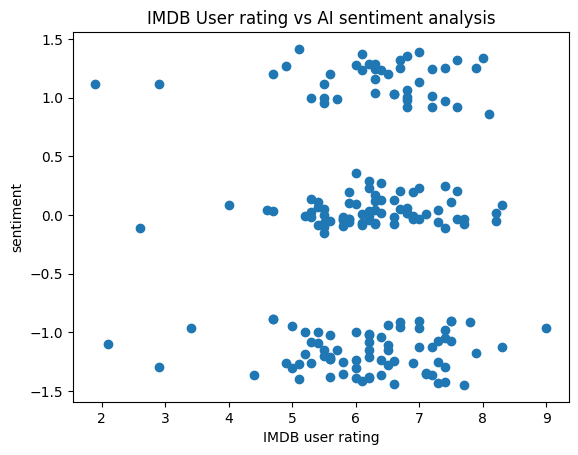

In [22]:
from matplotlib import pyplot

pyplot.scatter(unified_view['user_rating'], unified_view['sentiment'])
pyplot.title('IMDB User rating vs AI sentiment analysis')
pyplot.xlabel('IMDB user rating')
pyplot.ylabel('sentiment')

In [18]:
import seaborn as sns 



Chart 2: Scatter Plot of Budget vs. Gross Sales

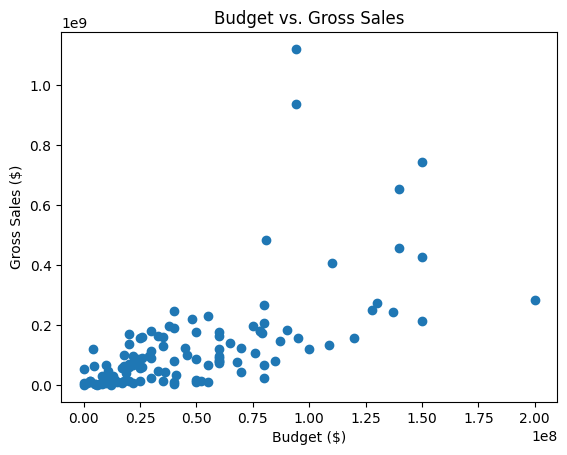

In [23]:
# Filter out rows where Budget_USD or Gross_Sales_USD is null
filtered_data = imdb_view[(imdb_view['Budget_USD'].notnull()) & (imdb_view['Gross_Sales_USD'].notnull())]

# Create the scatter plot
pyplot.scatter(x=filtered_data['Budget_USD'], y=filtered_data['Gross_Sales_USD'])
pyplot.xlabel('Budget ($)')
pyplot.ylabel('Gross Sales ($)')
pyplot.title('Budget vs. Gross Sales')
pyplot.show()


Chart 3: Gerne Count

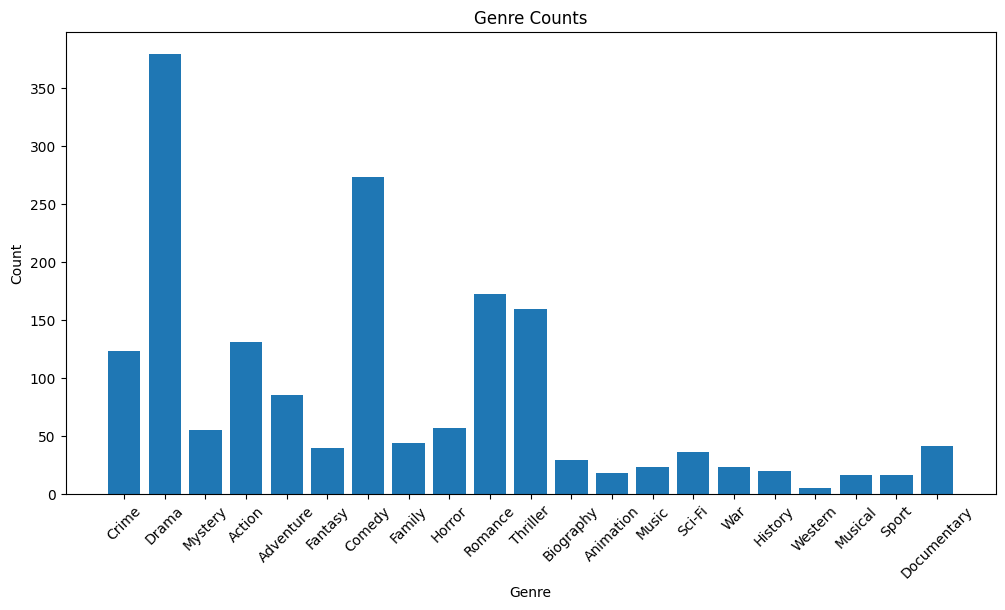

In [24]:
from collections import Counter

all_genres = [genre for movie_genres in imdb_view['genres'] for genre in movie_genres.split(', ')]

# Count the occurrences of each genre
genre_counts = Counter(all_genres)

# Create the bar chart
pyplot.figure(figsize=(12, 6))
pyplot.bar(genre_counts.keys(), genre_counts.values())
pyplot.xticks(rotation=45)
pyplot.xlabel('Genre')
pyplot.ylabel('Count')
pyplot.title('Genre Counts')
pyplot.show()


# What the plot teaches me 

It is seemed like that my prediction about the higher the sentiment score, the higher the IMDB user score is partialy correct. Chart 1 show me that even with a low sentiment score, the movie can still have a high IMDB user score. 

On chart 2, I can see it is a kind of linear regression chart where I can fit a line into the data point. Chart 2 can help me conclude that the movie with higher budget are likely to have a higher gross sales. However, there are outliers in the graph.

On chart 3, I can tell that the favourite gerne of all is drama. I can see that when using pandas dataframe, Drama is the tag that got the most in the gerne of movie. I can conclude that in my choice of year in 2003, Drama is the movie with the most count of all other gerne.